第1轮 | 训练损失为：0.320 训练准确率为：92.9% | 验证损失为：0.048 验证准确率为：98.4%
第2轮 | 训练损失为：0.017 训练准确率为：99.4% | 验证损失为：0.052 验证准确率为：97.8%
第3轮 | 训练损失为：0.024 训练准确率为：99.4% | 验证损失为：0.055 验证准确率为：97.9%
第4轮 | 训练损失为：0.009 训练准确率为：99.7% | 验证损失为：0.042 验证准确率为：99.1%
第5轮 | 训练损失为：0.014 训练准确率为：99.6% | 验证损失为：0.052 验证准确率为：98.8%
第6轮 | 训练损失为：0.031 训练准确率为：99.0% | 验证损失为：0.040 验证准确率为：99.1%
第7轮 | 训练损失为：0.010 训练准确率为：99.6% | 验证损失为：0.031 验证准确率为：99.4%
第8轮 | 训练损失为：0.008 训练准确率为：99.7% | 验证损失为：0.046 验证准确率为：99.0%
第9轮 | 训练损失为：0.008 训练准确率为：99.7% | 验证损失为：0.047 验证准确率为：99.0%
第10轮 | 训练损失为：0.008 训练准确率为：99.8% | 验证损失为：0.045 验证准确率为：99.1%
第11轮 | 训练损失为：0.007 训练准确率为：99.8% | 验证损失为：0.086 验证准确率为：98.7%
第12轮 | 训练损失为：0.003 训练准确率为：100.0% | 验证损失为：0.063 验证准确率为：99.4%
第13轮 | 训练损失为：0.013 训练准确率为：99.5% | 验证损失为：0.101 验证准确率为：97.2%
第14轮 | 训练损失为：0.052 训练准确率为：98.5% | 验证损失为：0.061 验证准确率为：98.7%
第15轮 | 训练损失为：0.008 训练准确率为：99.7% | 验证损失为：0.054 验证准确率为：99.4%
第16轮 | 训练损失为：0.006 训练准确率为：99.9% | 验证损失为：0.054 验证准确率为：99.0%
第17轮 | 训练损失为：0.004 训练准确率为：99.9% | 验证损失为：0.096 验证准确率为：98.2%
第18轮 

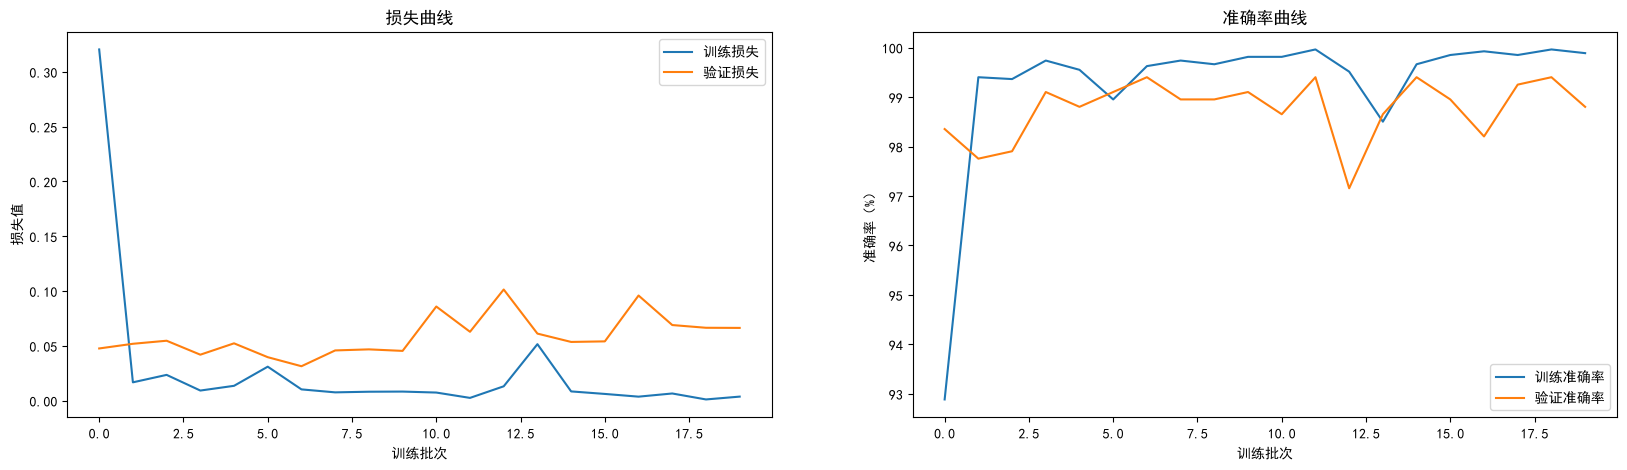

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9647058684825898].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9450980317592621].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.8901960670948028].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9921568908691407].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9058823310136794].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9764705595970153].


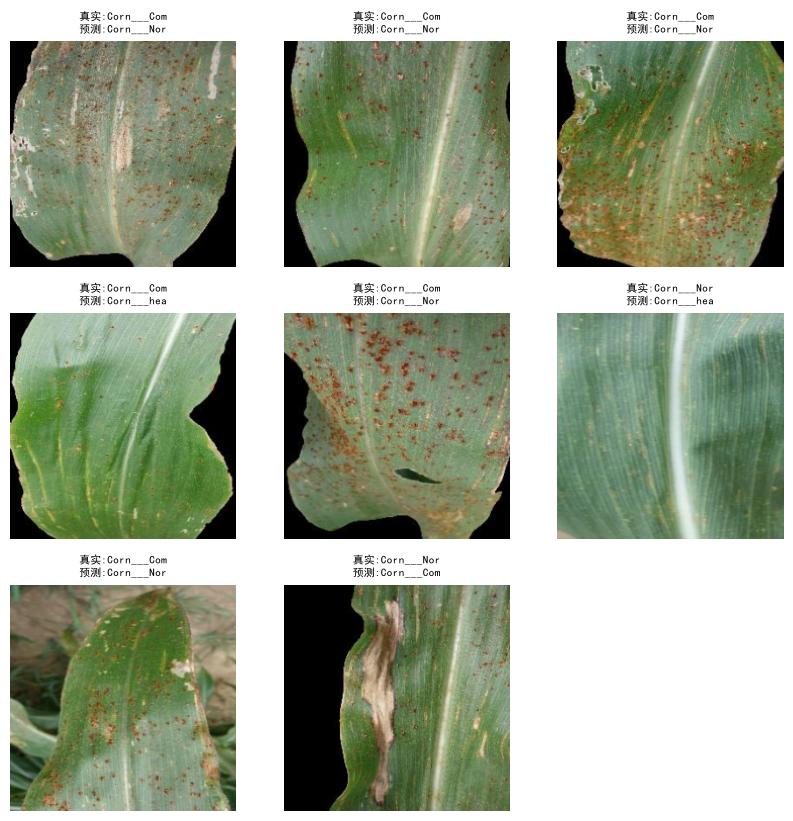

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets,transforms
from torch.utils.data import DataLoader,random_split
plt.rcParams["font.family"]=["SimHei"]
plt.rcParams["axes.unicode_minus"]=False

device='cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE=224 if device=='cuda' else 128
BATCH_SIZE=32
EPOCH=20

full_dataset=datasets.ImageFolder(root="./corn_disease")
train_size=int(0.8*len(full_dataset))
val_size=len(full_dataset)-train_size
train_idx,val_idx=random_split(full_dataset,[train_size,val_size])

transform_train=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])
transform_val=transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])
train_dataset=datasets.ImageFolder(root="./corn_disease",transform=transform_train)
val_dataset=datasets.ImageFolder(root="./corn_disease",transform=transform_val)
train_dataset=torch.utils.data.Subset(train_dataset,train_idx.indices)
val_dataset=torch.utils.data.Subset(val_dataset,val_idx.indices)
train_loader=DataLoader(train_dataset,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False)

class SimpleCornCNN(nn.Module):
    def __init__(self,num_classes=3):
        super().__init__()
        self.conv1=nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,padding=1)
        self.relu1=nn.ReLU()
        self.pool1=nn.MaxPool2d(2)
        self.conv2=nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,padding=1)
        self.relu2=nn.ReLU()
        self.pool2=nn.MaxPool2d(2)
        self.flatten=nn.Flatten()
        fc_input_size=32*(IMG_SIZE//4)*(IMG_SIZE//4)
        self.fc=nn.Linear(fc_input_size,num_classes)

    def forward(self,x):
        x=self.pool1(self.relu1(self.conv1(x)))
        x=self.pool2(self.relu2(self.conv2(x)))
        x=self.flatten(x)
        x=self.fc(x)
        return x

model=SimpleCornCNN(num_classes=3).to(device)

#现在已完成数据导入和模型编写，接下来进入跑模型。指标：平均损失、准确率
optimiser=torch.optim.Adam(model.parameters(),lr=0.001)
criterion=nn.CrossEntropyLoss()

history={
    "train_loss":[],
    "train_acc":[],
    "val_loss":[],
    "val_acc":[]
}
for epoch in range(EPOCH):
    model.train()
    train_loss=0.0
    train_correct=0
    train_total=0
    for images,labels in train_loader:
        optimiser.zero_grad()
        images=images.to(device)
        labels=labels.to(device)
        output=model(images)
        loss=criterion(output,labels)
        loss.backward()
        optimiser.step()

        train_loss+=loss.item()
        _,predicted=torch.max(output.data,1)
        train_correct+=(predicted==labels).sum().item()
        train_total+=labels.size(0)

    avg_train_loss=train_loss/len(train_loader)
    avg_train_acc=100*train_correct/train_total

    model.eval()
    with torch.no_grad():
        val_loss=0.0
        val_correct=0
        val_total=0
        for images,labels in val_loader:
            images=images.to(device)
            labels=labels.to(device)
            output=model(images)
            loss=criterion(output,labels)        
            val_loss+=loss.item()
            _,predicted=torch.max(output.data,1)
            val_correct+=(predicted==labels).sum().item()
            val_total+=labels.size(0)

    avg_val_loss=val_loss/len(val_loader)
    avg_val_acc=100*val_correct/val_total
    history["train_loss"].append(avg_train_loss)
    history["train_acc"].append(avg_train_acc)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(avg_val_acc)
    print(f"第{epoch+1}轮 | 训练损失为：{avg_train_loss:.3f} 训练准确率为：{avg_train_acc:.1f}% | 验证损失为：{avg_val_loss:.3f} 验证准确率为：{avg_val_acc:.1f}%")

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(history["train_loss"],label="训练损失")
plt.plot(history["val_loss"],label="验证损失")
plt.xlabel("训练批次")
plt.ylabel("损失值")
plt.title("损失曲线")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_acc"],label="训练准确率")
plt.plot(history["val_acc"],label="验证准确率")
plt.xlabel("训练批次")
plt.ylabel("准确率（%）")
plt.title("准确率曲线")
plt.legend()
plt.show()

#接下来打印预测错误的图片

wrong_images = []
wrong_labels = []
wrong_preds = []

model.eval()
with torch.no_grad():
    for images,labels in val_loader:
        images=images.to(device)
        labels=labels.to(device)
        output=model(images)
        loss=criterion(output,labels)
        _,predicted=torch.max(output.data,1)
        for i in range(len(labels)):
            if predicted[i]!=labels[i]:
                wrong_images.append(images[i].cpu())
                wrong_labels.append(labels[i])
                wrong_preds.append(predicted[i])
        if(len(wrong_images) >= 9):
            break
    
plt.figure(figsize=(10,10))
class_names=full_dataset.classes
show_count=min(9,len(wrong_images))
for i in range(show_count):
    plt.subplot(3,3,i+1)
    img = wrong_images[i].permute(1,2,0).numpy()
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    plt.imshow(img)
    plt.title(f"真实:{class_names[wrong_labels[i]][:10]}\n预测:{class_names[wrong_preds[i]][:10]}", fontsize=8)
    plt.axis('off')
plt.show()